In [4]:
import time
print("ok")
for i in range(5):
    print(f"    Iteration {i+1}/5", end="\r")
    # simulate some work
    time.sleep(1)
print("Done!            ")

ok
Done!            


In [2]:
from torchvision import datasets, transforms

dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
]))

# print all class labels
print("Class labels:", dataset.classes)

# find class for value 1
mapping = {i: label for i, label in enumerate(dataset.classes)}
print("Class for value 1:", mapping[1])

Class labels: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Class for value 1: 1 - one


Class counts: Counter({'1 - one': 6742, '7 - seven': 6265, '3 - three': 6131, '2 - two': 5958, '9 - nine': 5949, '0 - zero': 5923, '6 - six': 5918, '8 - eight': 5851, '4 - four': 5842, '5 - five': 5421})


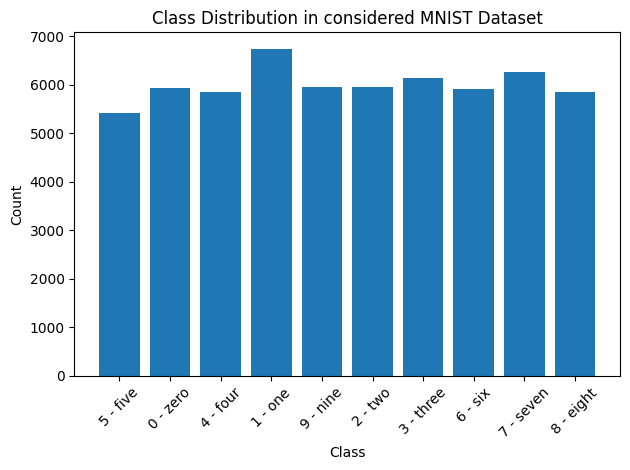

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

labels = [mapping[label] for _, label in dataset]
class_counts = Counter(labels)
print("Class counts:", class_counts)

plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution in considered MNIST Dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
import torch

b = 100  # Batch size
y_emb = torch.randn(b, 10)  # Example class embeddings for a batch of 16 samples and 10 classes
p_uncond = 0.2  # Probability of setting the embedding to zero (un

# Set empty in class embedding with probability p_uncond (See above)
rnd = torch.rand(b)
mul = torch.where(rnd < p_uncond, 0.0, 1.0)
y_emb = y_emb * mul[:,None]

print("Sample embeddings:")
for i in range(10):
    print(f"Embedding {i}: {y_emb[i]}")


Sample embeddings:
Embedding 0: tensor([-0.0302, -0.5284, -0.5651,  0.1835, -0.0030, -0.0481,  0.4334,  0.2485,
         0.2212, -1.7628])
Embedding 1: tensor([-1.3933, -1.1311,  2.3065, -1.3676, -0.1069,  0.0027, -1.4214, -1.6379,
         0.4067, -0.8623])
Embedding 2: tensor([-0.4297, -0.8245,  0.2196, -0.1219,  0.5734,  0.7605, -0.8027,  1.1420,
         0.6257,  0.8414])
Embedding 3: tensor([ 1.1931,  1.4223,  0.0426,  0.0892,  0.1291,  0.1699, -0.0303, -0.0157,
         0.1039,  0.3741])
Embedding 4: tensor([-0., -0., -0., -0., 0., -0., 0., -0., 0., 0.])
Embedding 5: tensor([ 0.7402, -0.4981,  0.5540, -0.0772, -0.8162, -1.6060,  0.2073,  0.8401,
         0.4084, -0.7248])
Embedding 6: tensor([ 1.2930, -0.8433, -2.1387, -0.6619, -0.2638,  0.2772, -0.1980,  0.1830,
        -0.1234, -0.4308])
Embedding 7: tensor([ 0.4677, -0.1867, -0.7815, -0.1688,  0.1880, -0.4747,  1.1161,  1.3209,
        -0.4135, -0.0273])
Embedding 8: tensor([ 0.5202, -0.9734, -0.3549,  0.5023, -1.7575, -0.4856